In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import MaxNLocator
from pandas import DataFrame
import machines
import programs
import scenarios.main.energyuq as energyuq

In [2]:
campaign_name = "energy"
campaign, analysis = energyuq.load(programs.NONE, machines.Glados, campaign_name)

sampler = energyuq.get_sampler(campaign)
qoi_cols = analysis.qoi_cols
qoi = "energy_uj"
results = campaign.get_last_analysis()


/home/mmachado/HPC/energyuq/.venv/lib/python3.9/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(


## Analysis of adaptation

The `adaptation_table` shows a plot of that visualizes which inputs got refined at what iteration.

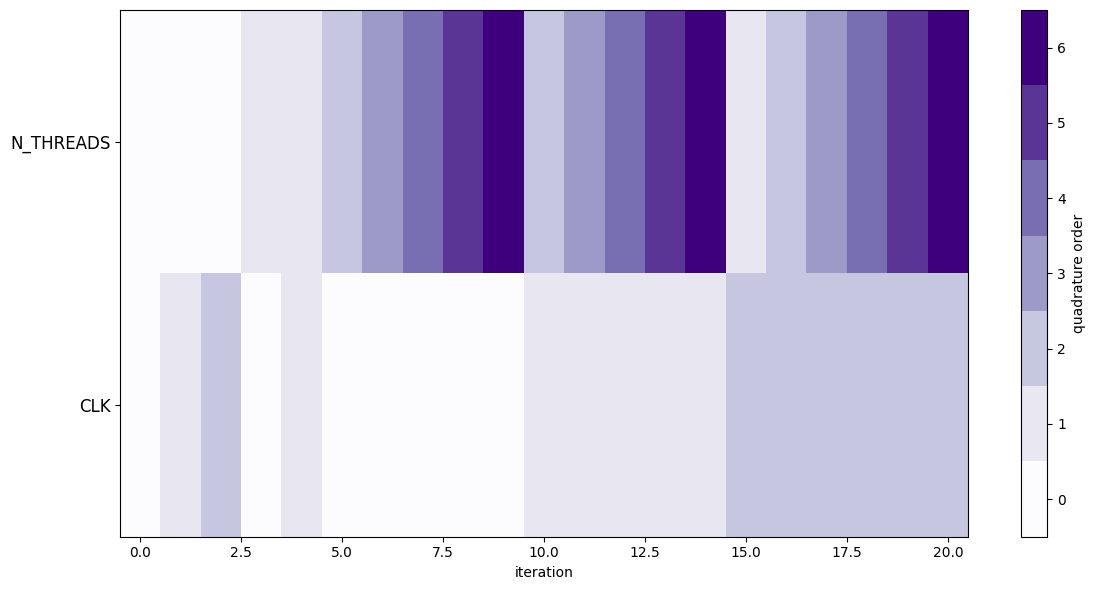

In [3]:
analysis.adaptation_table()

In [4]:
def plot_grid_2D():

    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R))
    
    ax=[]
    ic=0
    for i in range(L-1):
        xd = values[ic*2].upper[0] - values[ic*2].lower[0]
        yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
        ax.append(fig.add_subplot(R, C, ic+1,
                                  xlim=[values[ic*2].lower[0] - xd/10, values[ic*2].upper[0] + xd/10],
                                  ylim=[values[ic*2+1].lower[0] - yd/10, values[ic*2+1].upper[0] + yd/10], 
                                  xlabel=labels[ic*2], ylabel=labels[ic*2+1])
                 )
        ic += 1

    xd = values[ic*2].upper[0] - values[ic*2].lower[0]
    yd = values[ic*2+1].upper[0] - values[ic*2+1].lower[0]
    ax.append(fig.add_subplot(R, C, ic+1,
                              xlim=[values[-2].lower[0] - xd/10, values[-2].upper[0] + xd/10], 
                              ylim=[values[-1].lower[0] - yd/10, values[-1].upper[0] + yd/10], 
                              xlabel=labels[-2], ylabel=labels[-1])
             )

    accepted_grid = sampler.generate_grid(analysis.l_norm)

    ic=0
    for i in range(L-1):
        ax[i].plot(accepted_grid[:,ic*2], accepted_grid[:,ic*2+1], 'o', alpha=0.25)
        ic += 1
    ax[-1].plot(accepted_grid[:,-2], accepted_grid[:,-1], 'o', alpha=0.25)
    
    plt.tight_layout()

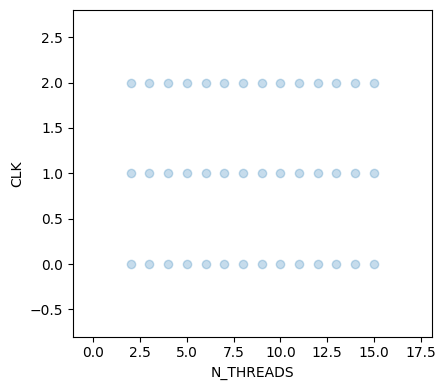

In [5]:
plot_grid_2D()

Since we are dealing with a polynomial test function, the (polynomial) SC approximation should be exact after sufficient iterations. In this case this happens after 10 iterations, and iteration 11 shown above does not improve the surrogate model further. This case be seen by examining the hierarchical surplus error values that were used to accept the multi indices into $\Lambda$. Note that the last two errors are essentially zero:

In [6]:
def get_confidence_intervals(samples, conf=0.9):
    """
    Compute the confidence intervals given an array of samples

    Parameters
    ----------
    samples : array
        Samples on which to compute the intervals.
    conf : float, optional, must be in [0, 1].
        The confidence interval percentage. The default is 0.9.

    Returns
    -------
    lower : array
        The lower confidence bound..
    upper : array
        The upper confidence bound.

    """

    # ake sure conf is in [0, 1]
    if conf < 0.0 or conf > 1.0:
        print('conf must be specified within [0, 1]')
        return

    # lower bound = alpha, upper bound = 1 - alpha
    alpha = 0.5 * (1.0 - conf)

    # arrays for lower and upper bound of the interval
    n_samples = samples.shape[0]
    N_qoi = samples.shape[1]
    lower = np.zeros(N_qoi)
    upper = np.zeros(N_qoi)

    # the probabilities of the ecdf
    prob = np.linspace(0, 1, n_samples)
    # the closest locations in prob that correspond to the interval bounds
    idx0 = np.where(prob <= alpha)[0][-1]
    idx1 = np.where(prob <= 1.0 - alpha)[0][-1]

    # for every location of qoi compute the ecdf-based confidence interval
    for i in range(N_qoi):
        # the sorted surrogate samples at the current location
        samples_sorted = np.sort(samples[:, i])
        # the corresponding confidence interval
        lower[i] = samples_sorted[idx0]
        upper[i] = samples_sorted[idx1]

    return lower, upper

In [7]:
mean_SC = results.describe(qoi, 'mean')
std_SC = results.describe(qoi, 'std')

Finally, we will create a plot with all first-order Sobol indices `S_i`, which shows the fraction of the output variance, that each input variable is responsible for *by itself*. To also estimate higher-order effects (the fraction of variance obtained by simultaneously varying 2 or more inputs together), we sum all first-order indices (shown in the first bar). Where this sum is close to one, there are (almost) no higher-order effects.

In [8]:
def plot_sobols1(qoi):
    inputs = list(sampler.vary.get_keys())
    d = len(inputs)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, title=r'First-order Sobol indices', ylim=[0,1])
    ax.set_ylabel(r'$S_i$', fontsize=14)
    
    sobols_first = np.array(list(results.sobols_first(qoi).values()))
    ax.bar(0, np.sum(sobols_first), color='salmon')
    ax.bar(np.arange(1, d+1), sobols_first.flatten(), color='dodgerblue')

    labels = ['Total first order']
    for i in range(d): labels.append(inputs[i])
    ax.set_xticks(np.arange(d+1))
    ax.set_xticklabels(labels, rotation=90)

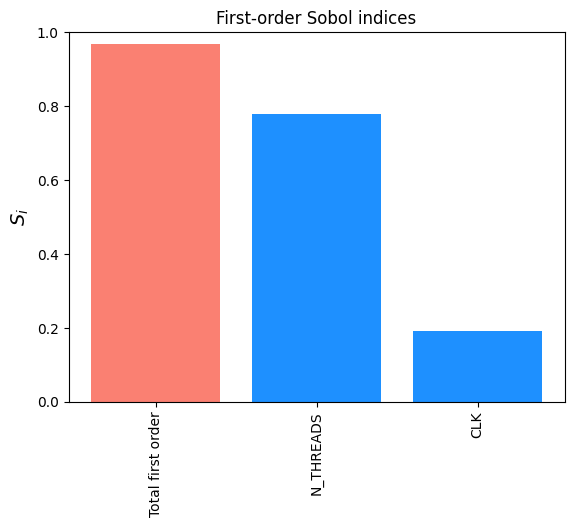

In [9]:
for qoi in qoi_cols:
    plot_sobols1(qoi)

/home/mmachado/HPC/energyuq/EasyVVUQ/src/easyvvuq/analysis/results.py:467: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


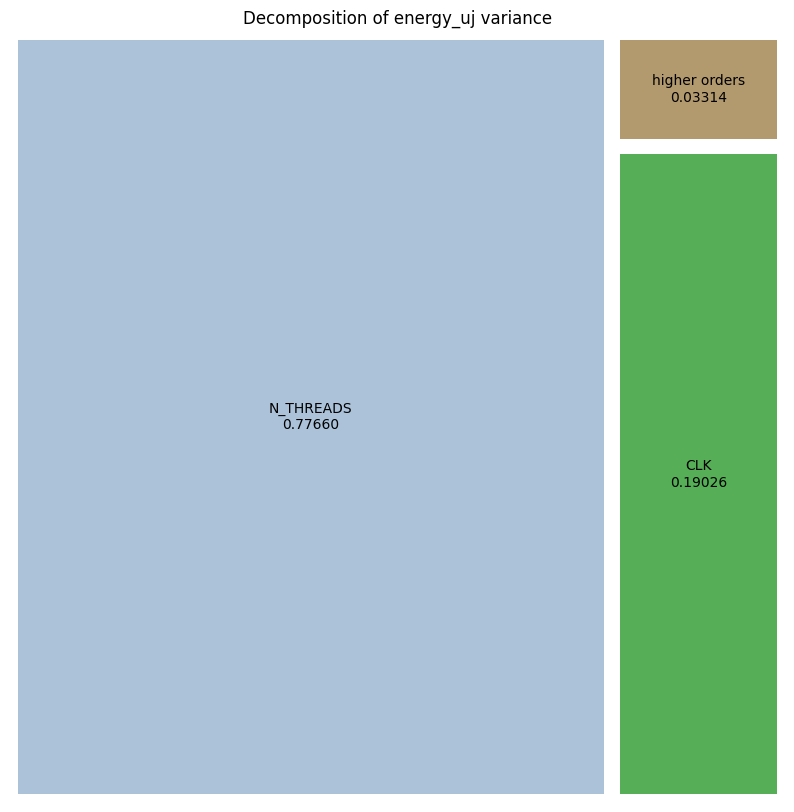

In [10]:
for qoi in qoi_cols:
    results.plot_sobols_treemap(qoi, figsize=(10, 10))
    plt.axis('off')

In [ ]:
from pandas import MultiIndex
import pandas


def plot_grid_2D_best():

    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = (len(labels)+1)//2
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))2800000

    fig = plt.figure(figsize=(12,12/C*R))
    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i*2].upper[0] - values[i*2].lower[0]
        yd = values[i*2+1].upper[0] - values[i*2+1].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i*2].lower[0] - xd/10, values[i*2].upper[0] + xd/10],
                                  ylim=[values[i*2+1].lower[0] - yd/10, values[i*2+1].upper[0] + yd/10], 
                                  xlabel=labels[i*2], ylabel=labels[i*2+1])
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    accepted_grid = sampler.generate_grid(analysis.l_norm)

    dataframe = campaign.get_collation_result()
    
    dataframe[f"{qoi}_norm"] = ((column := dataframe[qoi]) - column.min()) / (column.max() - column.min())
    colors = [ (y, 0, (1 - y), 1) for y in dataframe[f"{qoi}_norm"].to_numpy()]


    for i in range(L):
        xs = dataframe[(labels[i*2], 0)].to_numpy()
        ys = dataframe[(labels[i*2 + 1], 0)].to_numpy()
        ax[i].scatter(xs, ys, c=colors)
    
    plt.tight_layout()

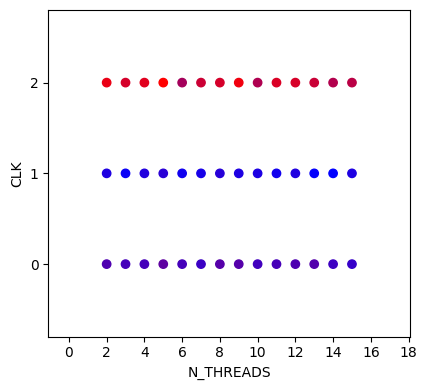

In [183]:
plot_grid_2D_best()

In [13]:
analysis.merge_accepted_and_admissible()
df = campaign.get_collation_result()
results = analysis.analyse(df)

print('Mean = %.4e' % results.describe(qoi, 'mean')[0])
print('Standard deviation = %.4e' % results.describe(qoi, 'std')[0])

Mean = 1.6034e+06
Standard deviation = 6.9228e+05


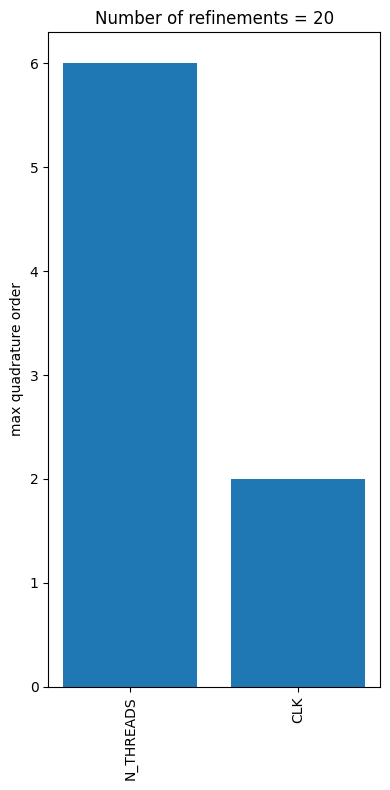

In [14]:
analysis.adaptation_histogram()

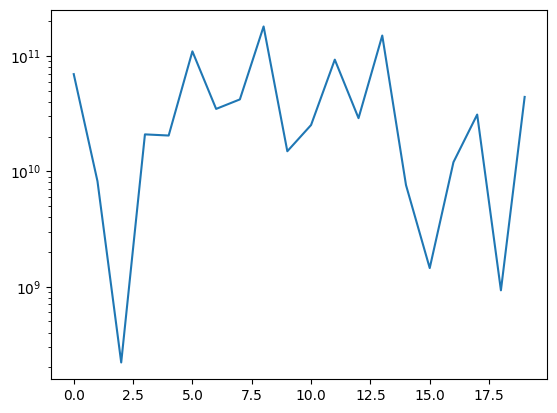

In [15]:
plt.semilogy(analysis.get_adaptation_errors())

In [16]:
analysis.get_uncertainty_amplification(qoi)

-----------------
Mean CV input = 67.9411 %
Mean CV output = 21.0919 %
Uncertainty amplification factor = 0.2109/0.6794 = 0.3104
-----------------


0.31044372198142334

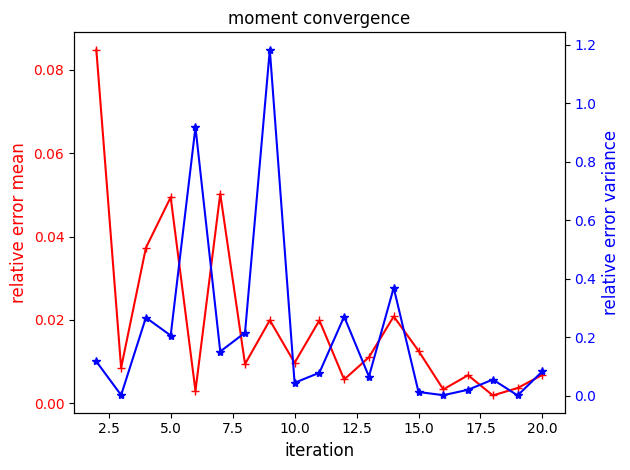

In [17]:
analysis.plot_stat_convergence()

In [18]:
def plot_sorted(dataframe):
    ### por que eres assim???????
    column_key = (qoi, 0)
    sorted_dataframe: DataFrame = dataframe.sort_values(by=column_key, ascending=False)


    plt.semilogy(sorted_dataframe[column_key].to_numpy())

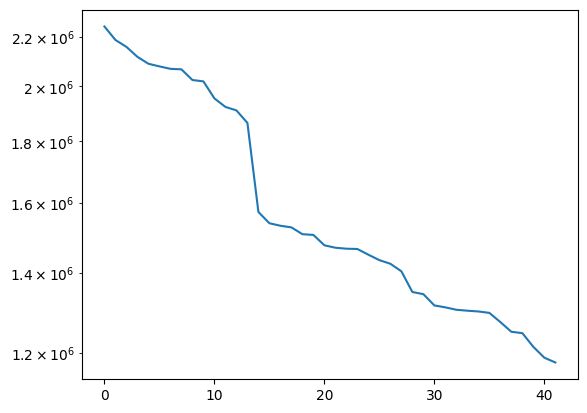

In [19]:
plot_sorted(campaign.get_collation_result())

In [45]:
def plot_2D_single_dimension():
    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R))
    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper[0] - values[i].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower[0] - xd/10, values[i].upper[0] + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i].interpret_as_integer))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    dataframe = campaign.get_collation_result()

    for i in range(L):
        ax[i].scatter(dataframe[labels[i], 0], dataframe[qoi, 0])
    
    plt.tight_layout()

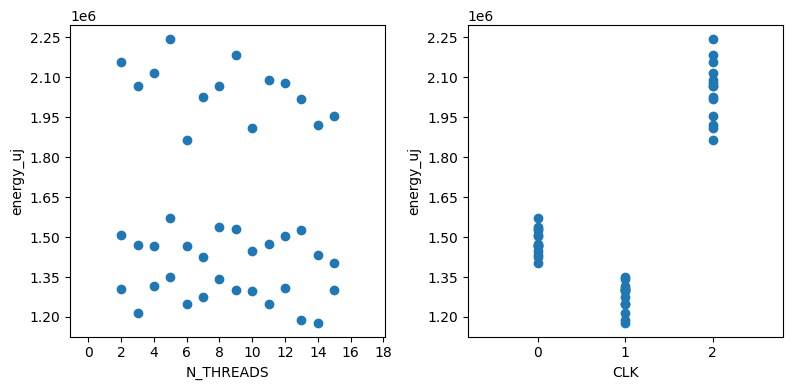

In [46]:
plot_2D_single_dimension()

In [128]:
def plot_boxplot():
    labels = list(sampler.vary.get_keys())
    values = list(sampler.vary.get_values())
    L = len(labels)
    C = int(np.ceil(np.sqrt((10+1)//2)))
    R = int(np.ceil(L / C))

    fig = plt.figure(figsize=(12,12/C*R))
    ax: list[Axes]=[]
    for i in range(L):
        xd = values[i].upper[0] - values[i].lower[0]
        ax.append(fig.add_subplot(R, C, i+1,
                                  xlim=[values[i].lower[0] - xd/10, values[i].upper[0] + xd/10],
                                  xlabel=labels[i], ylabel=qoi
                    )
                 )
        ax[-1].xaxis.set_major_locator(MaxNLocator(integer=values[i].interpret_as_integer))
        ax[-1].yaxis.set_major_locator(MaxNLocator(integer=True))

    dataframe = campaign.get_collation_result()

    # make data:
    np.random.seed(10)
    D = np.random.normal((3, 5, 4), (1.25, 1.00, 1.25), (100, 3))

    for i in range(L):
        qoi_c = (qoi, 0)
        label_c = (labels[i], 0)
        box_frame = dataframe[[qoi_c, label_c]].groupby(by=label_c)[[qoi_c]].apply(lambda x: x[qoi_c].to_numpy()) # pyright: ignore[reportArgumentType, reportCallIssue]

        VP = ax[i].boxplot(box_frame.to_numpy(),
                            positions=box_frame.index.to_numpy(),
                            patch_artist=True,
                            showmeans=False, showfliers=False, manage_ticks = False,
                            medianprops={"color": "white", "linewidth": 0.5},
                            boxprops={"facecolor": "C0", "edgecolor": "white", "linewidth": 0.5},
                            whiskerprops={"color": "C0", "linewidth": 1.5},
                            capprops={"color": "C0", "linewidth": 1.5}
                        )

    plt.tight_layout()

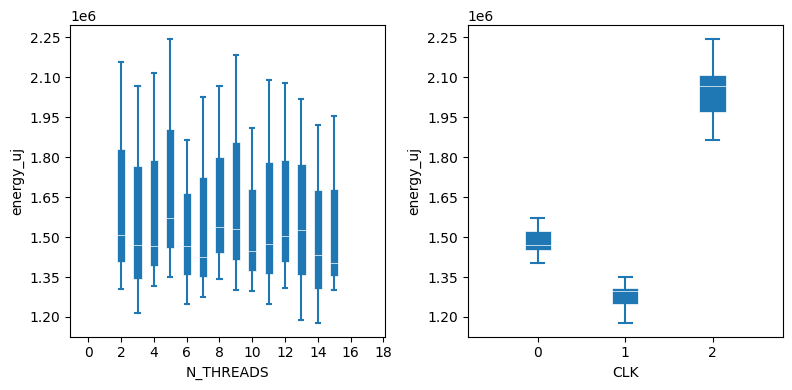

In [129]:
plot_boxplot()

In [51]:
np.random.normal((3, 5, 4), (1.25, 1.00, 1.25), (100, 3))

array([[3.94412495, 5.87948569, 3.70005463],
       [2.13117919, 4.52859992, 4.43684551],
       [5.01432162, 5.23933927, 4.60625329],
       [0.92674412, 7.67991031, 2.62059734],
       [5.27222826, 4.44395266, 5.19713905],
       [4.01902585, 5.0643194 , 3.79199329],
       [1.82411278, 4.9464055 , 5.37642025],
       [3.46515318, 4.11653901, 5.44756446],
       [1.49543314, 5.20983914, 2.88601635],
       [2.02164032, 6.07973068, 3.42144889],
       [1.1061554 , 4.46128147, 4.94577732],
       [2.08825097, 6.21478265, 5.26035371],
       [3.09160376, 6.17373241, 6.32868958],
       [0.52045438, 6.15668893, 4.76160283],
       [2.59599846, 5.66414561, 4.49590749],
       [2.27985392, 6.48821839, 4.17530858],
       [4.48539594, 4.75425461, 1.95551673],
       [3.30599761, 4.76491777, 2.42396524],
       [0.88504009, 5.61645092, 5.5871141 ],
       [4.74667247, 5.53422496, 4.00512755],
       [3.2367748 , 5.04477469, 4.99335659],
       [2.38357407, 3.73841026, 3.72592467],
       [3.

In [118]:
dataframe = campaign.get_collation_result()

dataframe[[(qoi, 0), ("N_THREADS", 0)]].groupby(by=("N_THREADS", 0))[[(qoi, 0)]].apply(lambda x: x[(qoi, 0)].to_numpy()).index

Index([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], dtype='int64', name=('N_THREADS', 0))